In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.1 MB/s eta 0:00:00


In [3]:
import torch
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA: True
GPU: Tesla T4


In [13]:
from pathlib import Path
import os

DATA_ROOT = Path("/content/lab6_data/dataset")

print("DATA_ROOT exists:", DATA_ROOT.exists())

for root, dirs, files in os.walk(DATA_ROOT):
    print(root, "| files:", len(files))
    if files:
        print(" sample:", files[:5])
    if root.count(os.sep) - str(DATA_ROOT).count(os.sep) > 2:
        break

DATA_ROOT exists: True
/content/lab6_data/dataset | files: 0
/content/lab6_data/dataset/sign_dataset | files: 0
/content/lab6_data/dataset/sign_dataset/train | files: 4109
 sample: ['1557.jpg_coco.json', '1589.jpg', '1600.jpg_coco.json', '1015.jpg', '1510.jpg_coco.json']
/content/lab6_data/dataset/sign_dataset/val | files: 255
 sample: ['2090.jpg', '2167.jpg_coco.json', '219.jpg_coco.json', '223.jpg', '2113.jpg']


In [14]:
import json
from pathlib import Path

TRAIN_DIR = DATA_ROOT / "sign_dataset" / "train"
VAL_DIR = DATA_ROOT / "sign_dataset" / "val"

sample_json = sorted(TRAIN_DIR.glob("*_coco.json"))[0]
print("Sample JSON file:", sample_json.name)

with open(sample_json, "r", encoding="utf-8") as f:
    sample_ann = json.load(f)

print(type(sample_ann))
print(sample_ann.keys() if isinstance(sample_ann, dict) else "Not a dict")
print(json.dumps(sample_ann, ensure_ascii=False, indent=2)[:3000])

Sample JSON file: 1.jpg_coco.json
<class 'dict'>
dict_keys(['masks', 'rois', 'scores', 'class_ids', 'bbox'])
{
  "masks": [
    [
      [
        false,
        false,
        false,
        false,
        false,
        false,
        false,
        false
      ],
      [
        false,
        false,
        false,
        false,
        false,
        false,
        false,
        true
      ],
      [
        false,
        false,
        false,
        true,
        false,
        false,
        false,
        true
      ],
      [
        false,
        false,
        false,
        true,
        false,
        false,
        true,
        true
      ],
      [
        false,
        false,
        false,
        true,
        false,
        false,
        true,
        true
      ],
      [
        false,
        false,
        false,
        true,
        false,
        false,
        true,
        true
      ],
      [
        false,
        false,
        false,
        false

In [15]:
if isinstance(sample_ann, dict) and "categories" in sample_ann:
    print("Categories:")
    for c in sample_ann["categories"]:
        print(c)
else:
    print("No 'categories' key found. Need to inspect structure manually.")

No 'categories' key found. Need to inspect structure manually.


In [16]:
import numpy as np

print("Keys:", sample_ann.keys())
print("Number of objects:", len(sample_ann["class_ids"]))
print("Class IDs:", sample_ann["class_ids"])

masks = sample_ann["masks"]
print("Number of masks:", len(masks))

first_mask = np.array(masks[0], dtype=np.uint8)
print("First mask shape:", first_mask.shape)
print("Unique values in first mask:", np.unique(first_mask))

print("ROIs:", sample_ann["rois"])
print("BBoxes:", sample_ann["bbox"])

Keys: dict_keys(['masks', 'rois', 'scores', 'class_ids', 'bbox'])
Number of objects: 8
Class IDs: [3, 3, 3, 3, 8, 3, 3, 3]
Number of masks: 56
First mask shape: (56, 8)
Unique values in first mask: [0 1]
ROIs: [[432, 325, 525, 453], [425, 7, 618, 351], [408, 546, 483, 624], [405, 486, 472, 519], [373, 477, 458, 557], [438, 289, 469, 347], [400, 404, 486, 506], [431, 2, 665, 82]]
BBoxes: [[433, 327, 517, 452], [438, 13, 609, 341], [409, 549, 481, 624], [408, 491, 470, 519], [375, 481, 455, 553], [438, 290, 465, 345], [400, 405, 484, 501], [431, 2, 665, 77]]


In [17]:
import json
from collections import Counter

def collect_class_ids(split_dir):
    json_files = sorted(split_dir.glob("*_coco.json"))
    counter = Counter()

    for jf in json_files:
        with open(jf, "r", encoding="utf-8") as f:
            ann = json.load(f)

        for cid in ann["class_ids"]:
            counter[int(cid)] += 1

    return counter

train_class_counter = collect_class_ids(TRAIN_DIR)
val_class_counter = collect_class_ids(VAL_DIR)

print("Train class counts:", train_class_counter)
print("Val class counts:", val_class_counter)

all_class_ids = sorted(set(train_class_counter.keys()) | set(val_class_counter.keys()))
print("All class ids:", all_class_ids)
print("Num classes:", len(all_class_ids))

Train class counts: Counter({3: 9933, 8: 1435, 1: 1378, 10: 597, 6: 111, 2: 19, 4: 14, 13: 2})
Val class counts: Counter({3: 531, 8: 86, 1: 84, 10: 28, 6: 9, 13: 1})
All class ids: [1, 2, 3, 4, 6, 8, 10, 13]
Num classes: 8


In [18]:
orig_class_ids = sorted(all_class_ids)
class_id_map = {orig_id: new_id for new_id, orig_id in enumerate(orig_class_ids)}

print("Class ID mapping:")
print(class_id_map)

Class ID mapping:
{1: 0, 2: 1, 3: 2, 4: 3, 6: 4, 8: 5, 10: 6, 13: 7}


In [19]:
import cv2
import numpy as np

def mask_to_polygons(binary_mask, min_points=3):
    contours, _ = cv2.findContours(
        binary_mask.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    polygons = []
    for cnt in contours:
        cnt = cnt.squeeze(axis=1)
        if cnt.ndim != 2 or cnt.shape[0] < min_points:
            continue
        polygons.append(cnt)
    return polygons


def normalize_polygon(poly, w, h):
    poly = poly.astype(np.float32)
    poly[:, 0] /= w
    poly[:, 1] /= h
    return poly

In [20]:
from PIL import Image
from pathlib import Path

def convert_annotation_to_yolo_seg_lines(image_path, json_path, class_id_map):
    with open(json_path, "r", encoding="utf-8") as f:
        ann = json.load(f)

    img = Image.open(image_path).convert("RGB")
    w, h = img.size

    lines = []

    masks = ann["masks"]
    class_ids = ann["class_ids"]

    for obj_idx, orig_cid in enumerate(class_ids):
        cid = class_id_map[int(orig_cid)]
        mask = np.array(masks[obj_idx], dtype=np.uint8)

        polygons = mask_to_polygons(mask)

        for poly in polygons:
            poly_n = normalize_polygon(poly, w, h)
            flat = poly_n.reshape(-1)

            # bỏ polygon quá ngắn
            if len(flat) < 6:
                continue

            line = str(cid) + " " + " ".join(f"{x:.6f}" for x in flat)
            lines.append(line)

    return lines

sample_img = TRAIN_DIR / sample_json.name.replace("_coco.json", "")
sample_lines = convert_annotation_to_yolo_seg_lines(sample_img, sample_json, class_id_map)

print("Sample image:", sample_img.name)
print("Number of YOLO-seg lines:", len(sample_lines))
print("First line:")
print(sample_lines[0][:300] if sample_lines else "No lines")

Sample image: 1.jpg
Number of YOLO-seg lines: 9
First line:
2 0.001563 0.011111 0.001563 0.038889 0.000781 0.040278 0.000000 0.040278 0.000000 0.045833 0.000781 0.047222 0.000781 0.056944 0.000781 0.051389 0.001563 0.050000 0.001563 0.027778 0.002344 0.026389 0.002344 0.025000 0.001563 0.023611 0.001563 0.022222 0.002344 0.020833 0.002344 0.019444 0.001563 0


In [23]:
# check tensor form of masks

masks_arr = np.array(sample_ann["masks"], dtype=np.uint8)

print("masks_arr shape:", masks_arr.shape)
print("masks_arr ndim:", masks_arr.ndim)
print("unique values:", np.unique(masks_arr))

masks_arr shape: (56, 56, 8)
masks_arr ndim: 3
unique values: [0 1]


In [24]:
#rewrite def convert annotation to yolo-segm

from PIL import Image
import numpy as np

def convert_annotation_to_yolo_seg_lines(image_path, json_path, class_id_map):
    with open(json_path, "r", encoding="utf-8") as f:
        ann = json.load(f)

    img = Image.open(image_path).convert("RGB")
    w, h = img.size

    masks_arr = np.array(ann["masks"], dtype=np.uint8)   # shape: (H, W, N)
    class_ids = ann["class_ids"]

    assert masks_arr.ndim == 3, f"Expected 3D masks tensor, got shape {masks_arr.shape}"
    assert masks_arr.shape[2] == len(class_ids), (
        f"Mismatch: masks last dim = {masks_arr.shape[2]}, num class_ids = {len(class_ids)}"
    )

    lines = []

    for obj_idx, orig_cid in enumerate(class_ids):
        cid = class_id_map[int(orig_cid)]
        mask = masks_arr[:, :, obj_idx]

        polygons = mask_to_polygons(mask)

        for poly in polygons:
            poly_n = normalize_polygon(poly, w, h)
            flat = poly_n.reshape(-1)

            # polygon phải có ít nhất 3 điểm => 6 số
            if len(flat) < 6:
                continue

            line = str(cid) + " " + " ".join(f"{x:.6f}" for x in flat)
            lines.append(line)

    return lines

In [28]:
sample_img = TRAIN_DIR / sample_json.name.replace("_coco.json", "")
sample_lines = convert_annotation_to_yolo_seg_lines(sample_img, sample_json, class_id_map)

print("Sample image:", sample_img.name)
print("Number of YOLO-seg lines:", len(sample_lines))
print("First line:")
print(sample_lines[0][:300] if sample_lines else "No lines")

Sample image: 1.jpg
Number of YOLO-seg lines: 8
First line:
2 0.022656 0.000000 0.021875 0.001389 0.014844 0.001389 0.014062 0.002778 0.012500 0.002778 0.011719 0.004167 0.009375 0.004167 0.007812 0.006944 0.007031 0.006944 0.005469 0.009722 0.005469 0.011111 0.003906 0.013889 0.003906 0.015278 0.003125 0.016667 0.003125 0.018056 0.002344 0.019444 0.002344 0


In [44]:
def show_sample_polygons_fixed(image_path, json_path, class_id_map):
    with open(json_path, "r", encoding="utf-8") as f:
        ann = json.load(f)

    img = np.array(Image.open(image_path).convert("RGB"))
    h, w = img.shape[:2]

    masks_arr = np.array(ann["masks"], dtype=np.uint8)   # (56,56,N)
    class_ids = ann["class_ids"]
    bboxes = ann["bbox"]

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    ax = plt.gca()

    for obj_idx, orig_cid in enumerate(class_ids):
        cid = class_id_map[int(orig_cid)]

        small_mask = masks_arr[:, :, obj_idx]

        # bbox = [y1, x1, y2, x2]
        y1, x1, y2, x2 = bboxes[obj_idx]

        box_h = y2 - y1
        box_w = x2 - x1

        # resize mask lên kích thước bbox
        mask_resized = cv2.resize(
            small_mask.astype(np.uint8),
            (box_w, box_h),
            interpolation=cv2.INTER_NEAREST
        )

        # tạo full mask
        full_mask = np.zeros((h, w), dtype=np.uint8)
        full_mask[y1:y2, x1:x2] = mask_resized

        polygons = mask_to_polygons(full_mask)

        for poly in polygons:
            patch = plt.Polygon(poly, fill=False, linewidth=2, edgecolor="red")
            ax.add_patch(patch)
            ax.text(poly[0, 0], poly[0, 1], str(cid), color="yellow", fontsize=10)

    plt.title(image_path.name)
    plt.axis("off")
    plt.show()

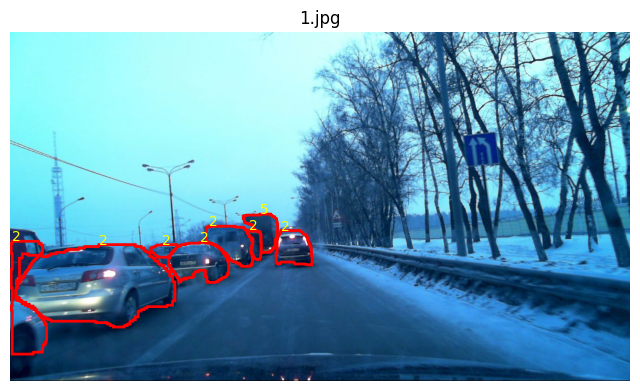

In [45]:
show_sample_polygons_fixed(sample_img, sample_json, class_id_map)

In [46]:
def convert_annotation_to_yolo_seg_lines(image_path, json_path, class_id_map):
    with open(json_path, "r", encoding="utf-8") as f:
        ann = json.load(f)

    img = Image.open(image_path).convert("RGB")
    w, h = img.size

    masks_arr = np.array(ann["masks"], dtype=np.uint8)   # (56,56,N)
    class_ids = ann["class_ids"]
    bboxes = ann["bbox"]

    lines = []

    for obj_idx, orig_cid in enumerate(class_ids):
        cid = class_id_map[int(orig_cid)]

        small_mask = masks_arr[:, :, obj_idx]

        # bbox = [y1, x1, y2, x2]
        y1, x1, y2, x2 = bboxes[obj_idx]

        box_h = y2 - y1
        box_w = x2 - x1

        if box_h <= 0 or box_w <= 0:
            continue

        # resize mask theo bbox
        mask_resized = cv2.resize(
            small_mask.astype(np.uint8),
            (box_w, box_h),
            interpolation=cv2.INTER_NEAREST
        )

        # full mask theo ảnh
        full_mask = np.zeros((h, w), dtype=np.uint8)
        full_mask[y1:y2, x1:x2] = mask_resized

        polygons = mask_to_polygons(full_mask)

        for poly in polygons:
            poly = poly.astype(np.float32)

            # normalize
            poly_n = normalize_polygon(poly, w, h)
            flat = poly_n.reshape(-1)

            if len(flat) < 6:
                continue

            line = str(cid) + " " + " ".join(f"{x:.6f}" for x in flat)
            lines.append(line)

    return lines

In [47]:
from pathlib import Path

YOLO_SEG_DIR = Path("/content/lab6_yolo_seg")

for p in [
    YOLO_SEG_DIR / "images" / "train",
    YOLO_SEG_DIR / "images" / "val",
    YOLO_SEG_DIR / "labels" / "train",
    YOLO_SEG_DIR / "labels" / "val",
]:
    p.mkdir(parents=True, exist_ok=True)

print("Folders ready")

Folders ready


In [49]:
import shutil

def export_split_to_yolo_seg(split_dir, split_name, class_id_map):
    json_files = sorted(split_dir.glob("*_coco.json"))

    for i, jf in enumerate(json_files):
        img_path = split_dir / jf.name.replace("_coco.json", "")
        if not img_path.exists():
            continue

        # copy image
        dst_img = YOLO_SEG_DIR / "images" / split_name / img_path.name
        shutil.copy(img_path, dst_img)

        # convert label
        lines = convert_annotation_to_yolo_seg_lines(img_path, jf, class_id_map)

        label_path = YOLO_SEG_DIR / "labels" / split_name / (img_path.stem + ".txt")
        with open(label_path, "w", encoding="utf-8") as f:
            for line in lines:
                f.write(line + "\n")

        if i % 500 == 0:
            print(f"{split_name}: processed {i}/{len(json_files)}")

In [51]:
export_split_to_yolo_seg(TRAIN_DIR, "train", class_id_map)
export_split_to_yolo_seg(VAL_DIR, "val", class_id_map)

print("Export done")

train: processed 0/2054
train: processed 500/2054
train: processed 1000/2054
train: processed 1500/2054
train: processed 2000/2054
val: processed 0/127
Export done


In [52]:
print("Train images:", len(list((YOLO_SEG_DIR / "images/train").glob("*.jpg"))))
print("Train labels:", len(list((YOLO_SEG_DIR / "labels/train").glob("*.txt"))))

print("Val images:", len(list((YOLO_SEG_DIR / "images/val").glob("*.jpg"))))
print("Val labels:", len(list((YOLO_SEG_DIR / "labels/val").glob("*.txt"))))

# check 1 vài file
sample_files = list((YOLO_SEG_DIR / "labels/train").glob("*.txt"))[:5]
for f in sample_files:
    print(f.name)
    print(f.read_text()[:200])
    print("-" * 30)

Train images: 2054
Train labels: 2054
Val images: 127
Val labels: 127
499.txt
6 0.468750 0.012500 0.468750 0.013889 0.467969 0.015278 0.449219 0.015278 0.448438 0.016667 0.448438 0.018056 0.447656 0.019444 0.447656 0.043056 0.448438 0.044444 0.448438 0.056944 0.449219 0.056944 
------------------------------
1349.txt
0 0.916406 0.525000 0.916406 0.526389 0.915625 0.527778 0.914844 0.527778 0.912500 0.531944 0.912500 0.534722 0.910937 0.537500 0.910156 0.537500 0.909375 0.538889 0.909375 0.541667 0.907812 0.544444 
------------------------------
1947.txt
5 0.260156 0.434722 0.260156 0.437500 0.259375 0.438889 0.258594 0.438889 0.258594 0.440278 0.257812 0.441667 0.256250 0.441667 0.256250 0.461111 0.257812 0.461111 0.258594 0.462500 0.258594 0.480556 
------------------------------
1236.txt
2 0.385156 0.512500 0.382812 0.516667 0.382812 0.525000 0.383594 0.526389 0.392969 0.526389 0.393750 0.525000 0.393750 0.515278 0.392188 0.512500
2 0.411719 0.498611 0.410156 0.501389 0.410156 0.5041

In [53]:
num_classes = len(class_id_map)

yaml_text = f"""
path: {YOLO_SEG_DIR.as_posix()}
train: images/train
val: images/val

names:
""".strip()

for i in range(num_classes):
    yaml_text += f"\n  {i}: sign_{i}"

yaml_path = YOLO_SEG_DIR / "roadsigns_seg.yaml"
yaml_path.write_text(yaml_text)

print(yaml_path.read_text())

path: /content/lab6_yolo_seg
train: images/train
val: images/val

names:
  0: sign_0
  1: sign_1
  2: sign_2
  3: sign_3
  4: sign_4
  5: sign_5
  6: sign_6
  7: sign_7


In [55]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")

results = model.train(
    data=str(yaml_path),
    epochs=20,
    imgsz=640,
    batch=16,
    project="/content/drive/MyDrive/lab6_runs",
    name="roadsigns_seg",
    device=0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/lab6_yolo_seg/roadsigns_seg.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv

In [56]:
from ultralytics import YOLO

best_model = YOLO("/content/drive/MyDrive/lab6_runs/roadsigns_seg/weights/best.pt")

metrics = best_model.val(
    data=str(yaml_path)
)

print(metrics)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,259,624 parameters, 0 gradients, 11.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2653.5±1418.8 MB/s, size: 100.4 KB)
val: Scanning /content/lab6_yolo_seg/labels/val.cache... 127 images, 12 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 127/127 8.6Mit/s 0.0s
val: /content/lab6_yolo_seg/images/val/207.jpg: corrupt JPEG restored and saved
val: /content/lab6_yolo_seg/images/val/211.jpg: corrupt JPEG restored and saved
val: /content/lab6_yolo_seg/images/val/213.jpg: corrupt JPEG restored and saved
val: /content/lab6_yolo_seg/images/val/214.jpg: corrupt JPEG restored and saved
val: /content/lab6_yolo_seg/images/val/216.jpg: corrupt JPEG restored and saved
val: /content/lab6_yolo_seg/images/val/223.jpg: corrupt JPEG restored and saved
val: /content/lab6_yolo_seg/images/val/225.jpg: corrupt JPEG restored and saved
val: /content/lab6_yolo_seg/images/val/231.jpg: 

In [57]:
sample_val_images = list((YOLO_SEG_DIR / "images/val").glob("*.jpg"))[:8]

best_model.predict(
    source=[str(p) for p in sample_val_images],
    save=True,
    conf=0.25
)


0: 640x640 7 sign_2s, 4 sign_5s, 7.3ms
1: 640x640 4 sign_2s, 7.3ms
2: 640x640 1 sign_6, 7.3ms
3: 640x640 2 sign_0s, 17 sign_2s, 1 sign_5, 7.3ms
4: 640x640 2 sign_2s, 7.3ms
5: 640x640 4 sign_2s, 1 sign_5, 7.3ms
6: 640x640 6 sign_2s, 1 sign_5, 7.3ms
7: 640x640 1 sign_5, 7.3ms
Speed: 2.2ms preprocess, 7.3ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: {0: 'sign_0', 1: 'sign_1', 2: 'sign_2', 3: 'sign_3', 4: 'sign_4', 5: 'sign_5', 6: 'sign_6', 7: 'sign_7'}
 obb: None
 orig_img: array([[[255, 253, 255],
         [255, 253, 255],
         [255, 253, 255],
         ...,
         [ 19,  18,  14],
         [ 20,  19,  15],
         [ 22,  21,  17]],
 
        [[255, 253, 255],
         [255, 253, 255],
         [255, 253, 255],
         ...,
         [ 21,  20,  16],
         [ 21,  20,  16],
         [ 21,  20,  16]],
 
        [[255, 253, 255],
         [255, 253, 255],
         [255, 253, 255],
         ...,
         [ 22,  21,  17],
         [ 21,  20,  16],
         [ 21,  20,  16]],
 
        ...,
 
        [[ 43,  42,  38],
         [ 43,  42,  38],
         [ 43,  42,  38],
         ...,
         [ 14,  17,   8],
         [ 13,  16,   7],
         [ 15

In [58]:
import json
import numpy as np
import cv2
from PIL import Image

def build_gt_union_mask(image_path, json_path):
    img = np.array(Image.open(image_path).convert("RGB"))
    h, w = img.shape[:2]

    with open(json_path, "r", encoding="utf-8") as f:
        ann = json.load(f)

    masks_arr = np.array(ann["masks"], dtype=np.uint8)   # (56,56,N)
    bboxes = ann["bbox"]

    gt_mask = np.zeros((h, w), dtype=np.uint8)

    num_objects = masks_arr.shape[2]

    for obj_idx in range(num_objects):
        small_mask = masks_arr[:, :, obj_idx]

        y1, x1, y2, x2 = bboxes[obj_idx]
        box_h = y2 - y1
        box_w = x2 - x1

        if box_h <= 0 or box_w <= 0:
            continue

        mask_resized = cv2.resize(
            small_mask.astype(np.uint8),
            (box_w, box_h),
            interpolation=cv2.INTER_NEAREST
        )

        gt_mask[y1:y2, x1:x2] = np.maximum(gt_mask[y1:y2, x1:x2], mask_resized)

    return gt_mask.astype(bool)

In [59]:
def build_pred_union_mask(result, image_shape):
    h, w = image_shape[:2]
    pred_mask = np.zeros((h, w), dtype=np.uint8)

    if result.masks is None:
        return pred_mask.astype(bool)

    masks = result.masks.data.cpu().numpy()  # (N, H, W)

    for m in masks:
        m_bin = (m > 0.5).astype(np.uint8)

        if m_bin.shape != (h, w):
            m_bin = cv2.resize(
                m_bin,
                (w, h),
                interpolation=cv2.INTER_NEAREST
            )

        pred_mask = np.maximum(pred_mask, m_bin)

    return pred_mask.astype(bool)

In [60]:
def compute_iou(pred_mask, gt_mask):
    inter = np.logical_and(pred_mask, gt_mask).sum()
    union = np.logical_or(pred_mask, gt_mask).sum()
    return inter / union if union > 0 else 1.0

def compute_precision(pred_mask, gt_mask):
    tp = np.logical_and(pred_mask, gt_mask).sum()
    fp = np.logical_and(pred_mask, np.logical_not(gt_mask)).sum()
    return tp / (tp + fp) if (tp + fp) > 0 else 1.0

def compute_recall(pred_mask, gt_mask):
    tp = np.logical_and(pred_mask, gt_mask).sum()
    fn = np.logical_and(np.logical_not(pred_mask), gt_mask).sum()
    return tp / (tp + fn) if (tp + fn) > 0 else 1.0

def compute_l2(pred_mask, gt_mask):
    return np.sqrt(((pred_mask.astype(np.float32) - gt_mask.astype(np.float32)) ** 2).mean())

In [64]:
from pathlib import Path
from ultralytics import YOLO
import numpy as np

best_model = YOLO("/content/drive/MyDrive/lab6_runs/roadsigns_seg/weights/best.pt")

val_image_paths = sorted((YOLO_SEG_DIR / "images/val").glob("*.jpg"))

iou_list = []
precision_list = []
recall_list = []
l2_list = []

for i, image_path in enumerate(val_image_paths):
    json_path = VAL_DIR / f"{image_path.name}_coco.json"
    if not json_path.exists():
        continue

    img = np.array(Image.open(image_path).convert("RGB"))

    gt_mask = build_gt_union_mask(image_path, json_path)

    pred_results = best_model.predict(
        source=str(image_path),
        conf=0.25,
        verbose=False
    )
    result = pred_results[0]

    pred_mask = build_pred_union_mask(result, img.shape)

    iou = compute_iou(pred_mask, gt_mask)
    precision = compute_precision(pred_mask, gt_mask)
    recall = compute_recall(pred_mask, gt_mask)
    l2 = compute_l2(pred_mask, gt_mask)

    iou_list.append(iou)
    precision_list.append(precision)
    recall_list.append(recall)
    l2_list.append(l2)

    if i % 10 == 0:
        print(f"Processed {i+1}/{len(val_image_paths)}")

Processed 1/127
Processed 11/127
Processed 21/127
Processed 31/127
Processed 41/127
Processed 51/127
Processed 61/127
Processed 71/127
Processed 81/127
Processed 91/127
Processed 101/127
Processed 111/127
Processed 121/127


In [65]:
print("Mean IoU:", np.mean(iou_list))
print("Mean Precision:", np.mean(precision_list))
print("Mean Recall:", np.mean(recall_list))
print("Mean L2:", np.mean(l2_list))

print("IoU >= 0.5:", np.mean(np.array(iou_list) >= 0.5))
print("IoU >= 0.75:", np.mean(np.array(iou_list) >= 0.75))
print("IoU >= 0.9:", np.mean(np.array(iou_list) >= 0.9))

Mean IoU: 0.6445854171594881
Mean Precision: 0.748394670437337
Mean Recall: 0.7948362614530781
Mean L2: 0.084216215
IoU >= 0.5: 0.7559055118110236
IoU >= 0.75: 0.4566929133858268
IoU >= 0.9: 0.10236220472440945


JPG: 127
PNG: 0
All files: 127
